In [1]:
import warnings
warnings.filterwarnings("ignore")

import scanpy as sc
import pandas as pd
import numpy as np
import liana.resource as lr
from tqdm.auto import tqdm

In [3]:
import scanpy as sc

adata = sc.read_h5ad(
    r"C:\BRCA\BRCA Project\data\IntegratedAtlas.h5ad",
    backed="r"
)

In [4]:
lr_db = lr.select_resource("consensus")

print(lr_db.head())
print(len(lr_db))

   ligand receptor
0  LGALS9    PTPRC
1  LGALS9      MET
2  LGALS9     CD44
3  LGALS9     LRP1
4  LGALS9     CD47
4624


In [5]:
donors = adata.obs["donor_id"].unique()

print(f"{len(donors)} patients")

138 patients


In [6]:
def build_patient_vector(adata, donor_id, lr_db):
    
    ad = adata[adata.obs["donor_id"] == donor_id].to_memory()

    ad.var_names = ad.var["feature_name"].astype(str)
    ad.var_names_make_unique()

    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

    expr = ad.to_df()
    expr["cell_type"] = ad.obs["cell_type"].values

    mean_expr = expr.groupby("cell_type").mean()

    scores = {}

    for _, row in lr_db.iterrows():

        lig = row["ligand"]
        rec = row["receptor"]

        if lig in mean_expr.columns and rec in mean_expr.columns:

            score = (
                mean_expr[lig].values *
                mean_expr[rec].values
            ).sum()

            feature = f"{lig}→{rec}"

            scores[feature] = float(score)

    return pd.Series(scores)

In [7]:
patient_vectors = {}

for donor in tqdm(donors):

    patient_vectors[donor] = build_patient_vector(
        adata,
        donor,
        lr_db
    )

100%|██████████| 138/138 [09:21<00:00,  4.07s/it]


In [8]:
communication_matrix = (
    pd.DataFrame(patient_vectors)
      .T
      .fillna(0)
)

communication_matrix.head()

,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47,LGALS9→PTPRK,LGALS9→COLEC12,LGALS9→HAVCR2,LGALS9→MRC2,DLL1→NOTCH1,...,BMP6→AMHR2,GDF11→ACTR2,GDF1→ACTR2,INHBA→ACTR2,BMP7→ACTR2,BMP2→ACTR2,BMP15→ACTR2,CSF1→CSF3R,IL36G→IFNAR1,IL36G→IFNAR2
wu_natgen_CID3586,8.633867,1.044805,8.393451,0.776248,3.758318,1.168318,0.296762,3.943516,0.637201,0.292995,...,0.000000e+00,0.546232,0.0,1.127656,0.008232,0.995683,0.0,0.114970,0.000000,0.000000
wu_natgen_CID3921,7.129786,0.670546,9.661072,2.296553,5.089897,1.524040,0.145497,2.765677,0.596229,0.356648,...,0.000000e+00,0.241065,0.0,2.798962,0.346355,0.568526,0.0,0.149420,0.000000,0.000000
wu_natgen_CID45171,8.077541,0.145614,7.158105,0.689071,4.376402,1.669631,0.300532,0.799553,0.391112,0.017953,...,0.000000e+00,2.182149,0.0,0.993794,0.057089,0.080615,0.0,0.032563,0.000000,0.000000
wu_natgen_CID3838,16.582199,2.095036,17.671549,3.576852,10.819265,2.728356,1.450304,5.477222,2.551522,2.010751,...,5.337549e-06,7.685503,0.0,7.648826,0.520871,3.494657,0.0,0.315217,0.003883,0.003169
wu_natgen_CID4066,6.538203,0.480212,4.661026,1.018777,4.621882,1.056085,0.198088,1.693815,0.611983,0.456659,...,6.623769e-07,0.439607,0.0,1.183399,0.088907,0.741925,0.0,0.104455,0.000000,0.000000


In [9]:
print(communication_matrix.shape)

(138, 3489)


In [11]:
communication_matrix.to_csv(
    r"C:\BRCA\BRCA Project\data\patient_communication_matrix.csv",
    index=True
)

In [12]:
print(communication_matrix.shape)

print(f"Patients: {communication_matrix.shape[0]}")
print(f"Features: {communication_matrix.shape[1]}")

communication_matrix.iloc[:5, :5]

(138, 3489)
Patients: 138
Features: 3489


,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47
wu_natgen_CID3586,8.633867,1.044805,8.393451,0.776248,3.758318
wu_natgen_CID3921,7.129786,0.670546,9.661072,2.296553,5.089897
wu_natgen_CID45171,8.077541,0.145614,7.158105,0.689071,4.376402
wu_natgen_CID3838,16.582199,2.095036,17.671549,3.576852,10.819265
wu_natgen_CID4066,6.538203,0.480212,4.661026,1.018777,4.621882


In [13]:
communication_matrix.isna().sum().sum()

np.int64(0)

In [14]:
communication_matrix.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
LGALS9→PTPRC,138.0,7.660364,5.225727,0.0,3.795492,6.691475,11.141993,27.209093
LGALS9→MET,138.0,1.035410,1.022493,0.0,0.202436,0.736750,1.578092,5.755347
LGALS9→CD44,138.0,7.389491,5.187245,0.0,3.384629,7.071317,10.763422,25.451920
LGALS9→LRP1,138.0,1.884183,1.557271,0.0,0.642465,1.673853,2.708545,7.961110
LGALS9→CD47,138.0,5.006755,3.596861,0.0,1.960702,4.050059,7.769777,15.795063
LGALS9→PTPRK,138.0,1.324989,1.047198,0.0,0.491597,1.155405,1.952160,5.303533
LGALS9→COLEC12,138.0,0.460277,0.589958,0.0,0.126781,0.280071,0.543173,4.012665
LGALS9→HAVCR2,138.0,2.401751,2.139897,0.0,0.852893,1.853286,3.446084,13.514687
LGALS9→MRC2,138.0,0.969424,1.068080,0.0,0.217735,0.635920,1.244545,5.625784
DLL1→NOTCH1,138.0,0.541366,0.600235,0.0,0.171260,0.358644,0.730831,4.211985


In [15]:
zero_fraction = (communication_matrix == 0).mean().mean()

print(f"Fraction of zeros: {zero_fraction:.3f}")

Fraction of zeros: 0.377


In [16]:
feature_variance = communication_matrix.var()

feature_variance.sort_values(ascending=False).head(20)

VIM→CD44        629.703092
HMGB1→CXCR4     598.977772
LGALS1→ITGB1    340.648035
HLA-B→CD3D      314.078256
TIMP1→CD63      286.002354
CD99→CD81       207.697970
LGALS1→PTPRC    189.221170
APP→CD74        182.974762
HLA-A→APLP2     181.331303
PKM→CD44        178.358125
TGFB1→CXCR4     165.604320
MIF→TNFRSF14    139.857481
HLA-B→KLRD1     112.211135
LGALS1→CD69     104.382871
COL1A1→CD44     101.589687
COL1A2→CD44      92.822057
TGFB1→ITGB1      84.919863
FN1→CD44         82.684236
AGTRAP→RACK1     80.766405
HLA-B→CD8A       71.037547
dtype: float64

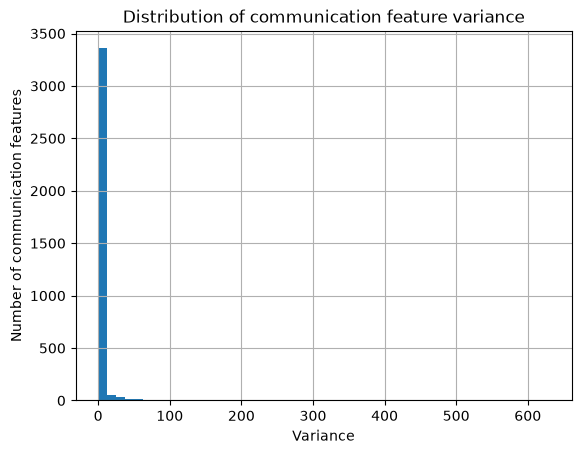

In [17]:
import matplotlib.pyplot as plt

feature_variance.hist(bins=50)

plt.xlabel("Variance")
plt.ylabel("Number of communication features")
plt.title("Distribution of communication feature variance")
plt.show()

In [ ]:
Patient communication matrix
↓

Discover latent communication programs
↓

Characterize programs

↓

Only THEN build XAI around them

In [22]:
%whos


Variable               Type           Data/Info
-----------------------------------------------
PCA                    ABCMeta        <class 'sklearn.decomposition._pca.PCA'>
adata                  AnnData        AnnData object with n_obs<...> obsm: 'X_rpca', 'X_umap'
build_patient_vector   function       <function build_patient_v<...>or at 0x0000028F4EB80EA0>
communication_matrix   DataFrame      Shape: (138, 3489)
donor                  str            wu_natgen_CID3586
donors                 Categorical    ['wu_natgen_CID3586', 'wu<...>1', 'wu_natgen_CID45171']
feature_variance       Series         Shape: (3489,)
lr                     module         <module 'liana.resource' <...>\\resource\\__init__.py'>
lr_db                  DataFrame      Shape: (4624, 2)
np                     module         <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
patient_vectors        dict           n=0
pca                    PCA            PCA(n_components=10)
pd                     module    

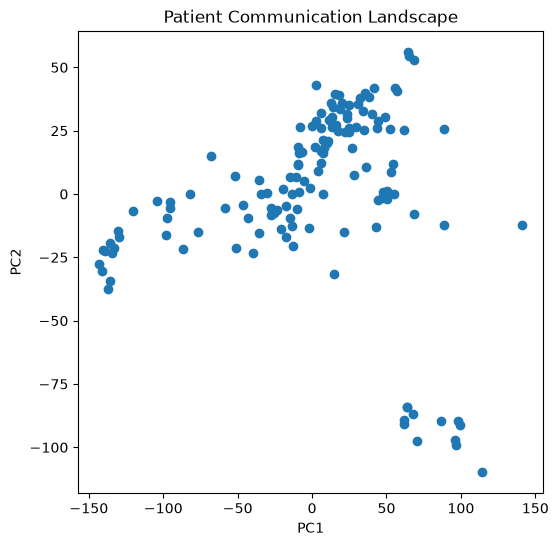

[0.39484127 0.13070301]


In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(communication_matrix)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Patient Communication Landscape")
plt.show()

print(pca.explained_variance_ratio_)

In [24]:
communication_matrix.to_csv(
    r"C:\BRCA\BRCA Project\data\patient_communication_matrix.csv"
)

In [25]:
import os

os.makedirs("outputs", exist_ok=True)

communication_matrix.to_csv(
    "outputs/communication_matrix.csv"
)

print("Saved:", communication_matrix.shape)

Saved: (138, 3489)


In [26]:
import os

print(os.getcwd())
print(os.listdir())

C:\BRCA\BRCA Project\data
['.ipynb_checkpoints', 'IntegratedAtlas.h5ad', 'integratedatlas_supplemental_files', 'outputs', 'patient_communication_matrix.csv', 'wu_spatial']


In [27]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if "communication" in f.lower():
            print(os.path.join(root, f))

.\patient_communication_matrix.csv
.\outputs\communication_matrix.csv
